In [6]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
# STEAD
#EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'
# UUSS
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
# 🔥 NAMA LAPORAN DIUBAH KHUSUS UNTUK UJI 1C Z TANPA TAUP
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def jalankan_stress_test_1C_Z_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...")
    # KITA HANYA MEMUAT EMBEDDING Z
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    
    try:
        # Menarik kurva PDF khusus untuk 1D (Z saja)
        embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    except AttributeError:
        print("❌ GALAT: Fungsi 'embedding_PDFs_1D' tidak ditemukan di library utils Bapak.")
        print("Mohon informasikan ke saya, kita akan pakai fungsi alternatif.")
        return
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform siap diuji buta temporal (1C-Z).")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing 1C-Z Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            # 🔥 HANYA MENARIK KOMPONEN Z
            comp_z = st.select(component="Z")
            if not comp_z: continue
            
            # Pemotongan Kaku Murni di Origin Time (Skenario Buta Temporal)
            detik_origin_kaku = 60.0
            
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            
            # Ekstraksi fitur 1D (Z)
            emb_le_z = utils.latent_codes_1D(le_z, embedding_model).reshape(1, -1)
            emb_no_z = utils.latent_codes_1D(no_z, embedding_model).reshape(1, -1)
            
            # Inferensi KDE 1D (Hanya membandingkan Z dengan kurva Z STEAD)
            p_le, _, _ = utils.infer_1C_PDFs(emb_le_z, embeddings_Z_PDFs, "Kernel")
            p_no, _, _ = utils.infer_1C_PDFs(emb_no_z, embeddings_Z_PDFs, "Kernel")
            
            # Label Swap Fix
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_1C_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_1C_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    print(f"🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : {skor_akurasi * 100:.2f} %")
    print("-" * 110)
    print("📋 LAPORAN METRIK BUKTI KERENTANAN 1C:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 110)
    print("📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 110)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> {PATH_FINAL_REPORT}\n")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_1C_Z_tanpa_taup()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...
   ✅ Sukses Mengunci: 55,699 berkas waveform siap diuji buta temporal (1C-Z).

⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...


Processing 1C-Z Unaligned Seismograms: 100%|██████████| 55699/55699 [17:54<00:00, 51.86it/s]



📊================================== 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) ==================================
🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : 70.26 %
--------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK BUKTI KERENTANAN 1C:
                precision    recall  f1-score   support

     Noise (0)       0.63      1.00      0.77     55699
Earthquake (1)       1.00      0.41      0.58     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398

--------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):
[[55683    16]
 [33113 22586]]
📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_true_1C

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...
   ✅ Sukses Mengunci: 55,699 berkas waveform siap diuji buta temporal (1C-Z).

⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...


Processing 1C-Z Unaligned Seismograms: 100%|██████████| 55699/55699 [16:24<00:00, 56.56it/s]



📊================================== 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) ==================================
🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : 70.26 %
--------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK BUKTI KERENTANAN 1C:
                precision    recall  f1-score   support

     Noise (0)       0.63      1.00      0.77     55699
Earthquake (1)       1.00      0.41      0.58     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398

--------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):
[[55683    16]
 [33113 22586]]
📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_true_1C

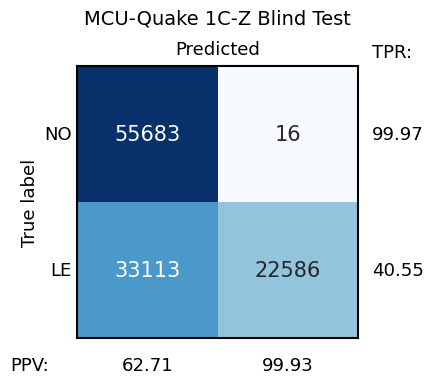

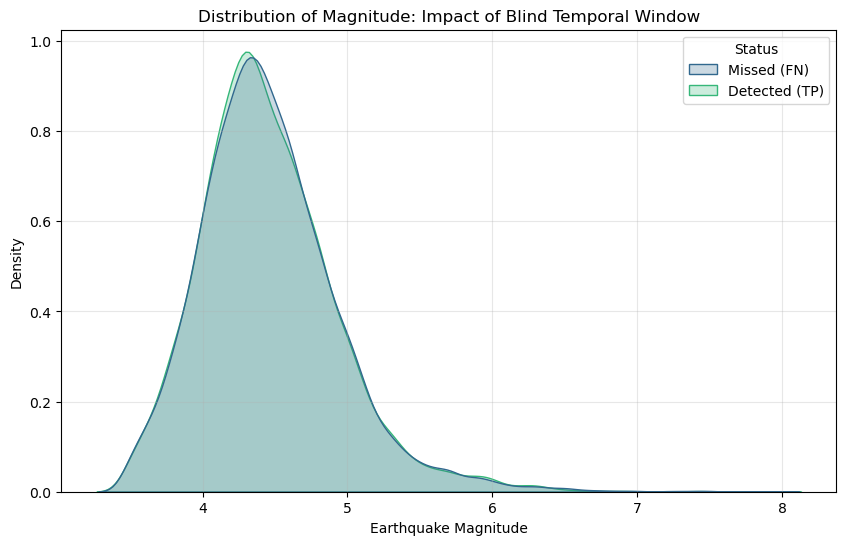

In [15]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
# STEAD
#EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'
# UUSS
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
# 🔥 NAMA LAPORAN DIUBAH KHUSUS UNTUK UJI 1C Z TANPA TAUP
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

# ==============================================================================
# 📊 FUNGSI VISUALISASI LENGKAP (GAYA PAPER IEEE / JURNAL)
# ==============================================================================
def plot_paper_style_cm(cm, title="MCU-Quake 1C-Z (No TauP)"):
    """Visualisasi Confusion Matrix gaya Paper dengan TPR dan PPV."""
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]

    TPR_NO = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    TPR_LE = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    PPV_NO = (TN / (TN + FN)) * 100 if (TN + FN) > 0 else 0.0
    PPV_LE = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0

    fig, ax = plt.subplots(figsize=(4.5, 4))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['', ''], yticklabels=['NO', 'LE'],
                annot_kws={"size": 15}, ax=ax)

    ax.set_title(title, fontsize=14, pad=30, loc='center')
    ax.set_ylabel('True label', fontsize=13)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Predicted', fontsize=13, labelpad=5)
    plt.yticks(fontsize=13, rotation=0)
    ax.tick_params(axis='both', which='both', length=0)

    # Tambahkan teks metrik TPR dan PPV
    ax.text(2.1, -0.1, 'TPR:', fontsize=13, ha='left', va='center')
    ax.text(2.1, 0.5, f'{TPR_NO:.2f}', fontsize=13, ha='left', va='center')
    ax.text(2.1, 1.5, f'{TPR_LE:.2f}', fontsize=13, ha='left', va='center')
    
    ax.text(-0.2, 2.2, 'PPV:', fontsize=13, ha='right', va='center')
    ax.text(0.5, 2.2, f'{PPV_NO:.2f}', fontsize=13, ha='center', va='center')
    ax.text(1.5, 2.2, f'{PPV_LE:.2f}', fontsize=13, ha='center', va='center')

    # Border hitam
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.savefig('paper_style_cm_1C_Z.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualisasi_hasil_riset(report_path, catalog_path):
    print("\n📈 MENJALANKAN MODUL VISUALISASI EVALUASI...")
    df_report = pd.read_csv(report_path)
    df_catalog = pd.read_csv(catalog_path)
    
    # 1. Plot Confusion Matrix Gaya Paper
    y_true = df_report['Type'].apply(lambda x: 1 if 'LE' in x else 0).tolist()
    y_pred = df_report['Decision'].tolist()
    cm = confusion_matrix(y_true, y_pred)
    plot_paper_style_cm(cm, title="MCU-Quake 1C-Z Blind Test")

    # 2. KDE Plot Magnitudo
    df_report['id'] = df_report['File'].astype(str).str.strip()
    col_id_cat = next((c for c in df_catalog.columns if 'id' in c.lower()), df_catalog.columns[0])
    df_catalog = df_catalog.rename(columns={col_id_cat: 'id'})
    df_catalog['id'] = df_catalog['id'].astype(str).str.strip()
    
    df_merged = df_report.merge(df_catalog, on='id', how='inner')
    df_gempa = df_merged[df_merged['Type'].str.contains('LE')].copy()
    df_gempa['Status'] = df_gempa['Decision'].apply(lambda x: 'Detected (TP)' if x == 1 else 'Missed (FN)')
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_gempa, x='magnitude', hue='Status', fill=True, common_norm=False, palette='viridis')
    plt.title('Distribution of Magnitude: Impact of Blind Temporal Window')
    plt.xlabel('Earthquake Magnitude')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    plt.savefig('magnitude_detection_density.png', dpi=300)
    plt.show()

# ==============================================================================
# 🚀 CORE PROCESS: INFERENSI STRESS-TEST
# ==============================================================================
def jalankan_stress_test_1C_Z_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    
    try:
        embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    except AttributeError:
        print("❌ GALAT: Fungsi 'embedding_PDFs_1D' tidak ditemukan.")
        return
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform siap diuji buta temporal (1C-Z).")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing 1C-Z Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            if not comp_z: continue
            
            detik_origin_kaku = 60.0
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            
            emb_le_z = utils.latent_codes_1D(le_z, embedding_model).reshape(1, -1)
            emb_no_z = utils.latent_codes_1D(no_z, embedding_model).reshape(1, -1)
            
            p_le, _, _ = utils.infer_1C_PDFs(emb_le_z, embeddings_Z_PDFs, "Kernel")
            p_no, _, _ = utils.infer_1C_PDFs(emb_no_z, embeddings_Z_PDFs, "Kernel")
            
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_1C_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_1C_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    print(f"🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : {skor_akurasi * 100:.2f} %")
    print("-" * 110)
    print("📋 LAPORAN METRIK BUKTI KERENTANAN 1C:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 110)
    print("📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 110)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    # 🔥 OTOMATIS MEMBUAT VISUALISASI SETELAH INFERENSI
    try:
        visualisasi_hasil_riset(PATH_FINAL_REPORT, PATH_KATALOG_MASTER)
    except Exception as e:
        print(f"⚠️ Catatan: Visualisasi gagal dibuat. Error: {e}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_1C_Z_tanpa_taup()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...
   ✅ Sukses Mengunci: 55,699 berkas waveform siap diuji buta temporal (1C-Z).

⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...


Processing 1C-Z Unaligned Seismograms: 100%|██████████| 55699/55699 [17:04<00:00, 54.39it/s]



📊================================== 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) ==================================
🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : 70.26 %
--------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK BUKTI KERENTANAN 1C:
                precision    recall  f1-score   support

     Noise (0)       0.63      1.00      0.77     55699
Earthquake (1)       1.00      0.41      0.58     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398

--------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):
[[55683    16]
 [33113 22586]]
📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_true_1C

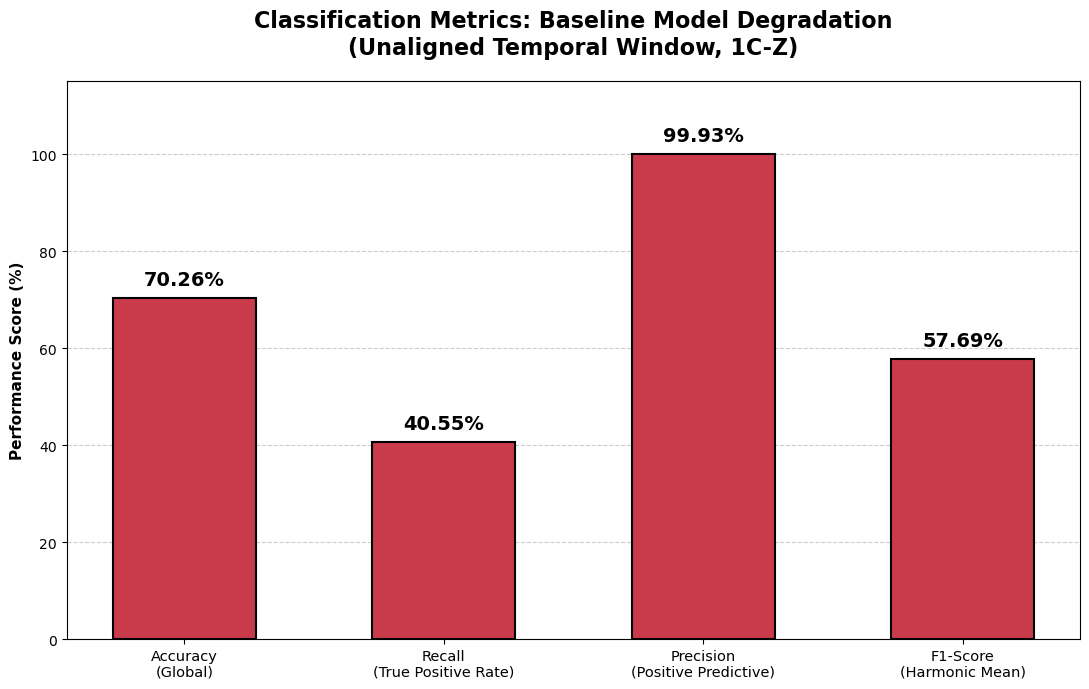

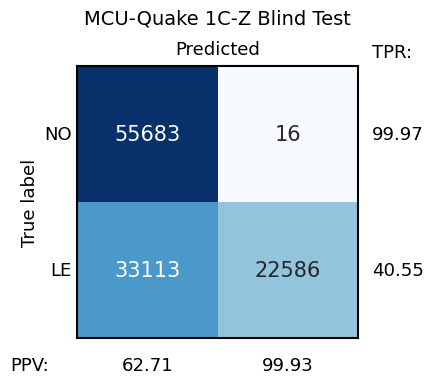

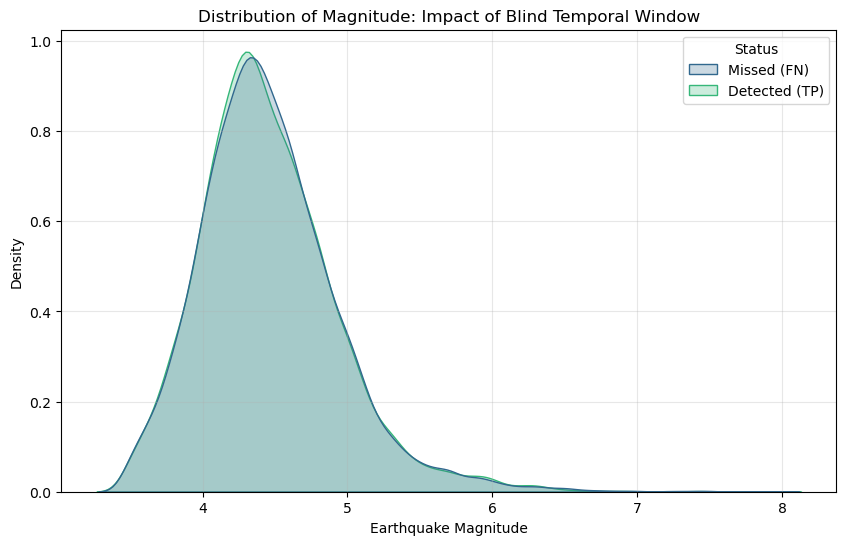

In [17]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
# UUSS
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
# 🔥 NAMA LAPORAN DIUBAH KHUSUS UNTUK UJI 1C Z TANPA TAUP
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

# ==============================================================================
# 📊 MODUL VISUALISASI LENGKAP (GAYA PAPER & JURNAL)
# ==============================================================================
def plot_paper_style_cm(cm, title="MCU-Quake 1C-Z (No TauP)"):
    """1. Visualisasi Confusion Matrix Heatmap dengan Metrik Marginal."""
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]

    TPR_NO = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0
    TPR_LE = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    PPV_NO = (TN / (TN + FN)) * 100 if (TN + FN) > 0 else 0.0
    PPV_LE = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0

    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['', ''], yticklabels=['NO', 'LE'], annot_kws={"size": 15}, ax=ax)

    ax.set_title(title, fontsize=14, pad=30, loc='center')
    ax.set_ylabel('True label', fontsize=13)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Predicted', fontsize=13, labelpad=5)
    plt.yticks(fontsize=13, rotation=0)
    ax.tick_params(axis='both', which='both', length=0)

    ax.text(2.1, -0.1, 'TPR:', fontsize=13, ha='left', va='center')
    ax.text(2.1, 0.5, f'{TPR_NO:.2f}', fontsize=13, ha='left', va='center')
    ax.text(2.1, 1.5, f'{TPR_LE:.2f}', fontsize=13, ha='left', va='center')
    ax.text(-0.2, 2.2, 'PPV:', fontsize=13, ha='right', va='center')
    ax.text(0.5, 2.2, f'{PPV_NO:.2f}', fontsize=13, ha='center', va='center')
    ax.text(1.5, 2.2, f'{PPV_LE:.2f}', fontsize=13, ha='center', va='center')

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)

    plt.subplots_adjust(right=0.75, bottom=0.2)
    plt.savefig('paper_style_cm_1C_Z.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_bar_metrics_paper_style(cm):
    """2. Visualisasi Bar Chart Metrik Degradasi."""
    TN, FP = cm[0, 0], cm[0, 1]
    FN, TP = cm[1, 0], cm[1, 1]
    
    acc = ((TP + TN) / (TP + TN + FP + FN)) * 100
    rec = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
    prec = (TP / (TP + FP)) * 100 if (TP + FP) > 0 else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    categories = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
    values = [acc, rec, prec, f1]

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.bar(categories, values, color='#c93b4a', edgecolor='black', linewidth=1.5, width=0.55)

    ax.set_ylim(0, 115)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_ylabel('Performance Score (%)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(axis='x', labelsize=10.5)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.2f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_title("Classification Metrics: Baseline Model Degradation\n(Unaligned Temporal Window, 1C-Z)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('bar_chart_metrics_degradation.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualisasi_hasil_riset(report_path, catalog_path):
    print("\n📈 MENJALANKAN MODUL VISUALISASI EVALUASI...")
    df_report = pd.read_csv(report_path)
    df_catalog = pd.read_csv(catalog_path)
    
    # Hitung Confusion Matrix untuk memanggil fungsi plotting
    y_true = df_report['Type'].apply(lambda x: 1 if 'LE' in x else 0).tolist()
    y_pred = df_report['Decision'].tolist()
    cm = confusion_matrix(y_true, y_pred)
    
    # Panggil visualisasi bar chart dan heatmap
    plot_bar_metrics_paper_style(cm)
    plot_paper_style_cm(cm, title="MCU-Quake 1C-Z Blind Test")

    # 3. KDE Plot Magnitudo
    df_report['id'] = df_report['File'].astype(str).str.strip()
    col_id_cat = next((c for c in df_catalog.columns if 'id' in c.lower()), df_catalog.columns[0])
    df_catalog = df_catalog.rename(columns={col_id_cat: 'id'})
    df_catalog['id'] = df_catalog['id'].astype(str).str.strip()
    
    df_merged = df_report.merge(df_catalog, on='id', how='inner')
    df_gempa = df_merged[df_merged['Type'].str.contains('LE')].copy()
    df_gempa['Status'] = df_gempa['Decision'].apply(lambda x: 'Detected (TP)' if x == 1 else 'Missed (FN)')
    
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_gempa, x='magnitude', hue='Status', fill=True, common_norm=False, palette='viridis')
    plt.title('Distribution of Magnitude: Impact of Blind Temporal Window')
    plt.xlabel('Earthquake Magnitude')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3)
    plt.savefig('magnitude_detection_density.png', dpi=300)
    plt.show()

# ==============================================================================
# 🚀 CORE PROCESS: INFERENSI STRESS-TEST
# ==============================================================================
def jalankan_stress_test_1C_Z_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...")
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    
    try:
        embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    except AttributeError:
        print("❌ GALAT: Fungsi 'embedding_PDFs_1D' tidak ditemukan.")
        return
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform siap diuji buta temporal (1C-Z).")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing 1C-Z Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            comp_z = st.select(component="Z")
            if not comp_z: continue
            
            detik_origin_kaku = 60.0
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            
            emb_le_z = utils.latent_codes_1D(le_z, embedding_model).reshape(1, -1)
            emb_no_z = utils.latent_codes_1D(no_z, embedding_model).reshape(1, -1)
            
            p_le, _, _ = utils.infer_1C_PDFs(emb_le_z, embeddings_Z_PDFs, "Kernel")
            p_no, _, _ = utils.infer_1C_PDFs(emb_no_z, embeddings_Z_PDFs, "Kernel")
            
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_1C_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_1C_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    print(f"🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : {skor_akurasi * 100:.2f} %")
    print("-" * 110)
    print("📋 LAPORAN METRIK BUKTI KERENTANAN 1C:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 110)
    print("📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 110)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> {PATH_FINAL_REPORT}\n")
    
    # 🔥 OTOMATIS MEMBUAT VISUALISASI SETELAH INFERENSI
    try:
        visualisasi_hasil_riset(PATH_FINAL_REPORT, PATH_KATALOG_MASTER)
    except Exception as e:
        print(f"⚠️ Catatan: Visualisasi gagal dibuat. Error: {e}")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_1C_Z_tanpa_taup()